In [1]:
!pip install open-clip-torch ultralytics hnswlib
!pip install pi-heif

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00
  Created wheel for hnswlib: filename=hnswlib-0.8.0-cp312-cp312-linux_x86_64.whl size=2733575 sha256=ec96bd07105c6d0741978fa2fdb9bd7e7e7768cffb2578b0ec0debc397954433
  Stored in directory: /root/.cache/pip/wheels/ac/39/b3/cbd7f9cbb76501d2d5fbc84956e70d0b94e788aac87bda465e
Successfully built hnswlib
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.5 MB/s eta 0:00:0000:010:01


In [2]:
import os, json, pickle
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm import tqdm
import open_clip
from ultralytics import YOLO
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import matplotlib.pyplot as plt
import hnswlib

DATASET_ROOT  = '/kaggle/input/datasets/adityarao061/inshopretreival/Dataset/Dataset'
ALPHA         = 0.7        
BATCH_SIZE    = 32         
CLIP_MODEL    = "ViT-B-32" 
YOLO_MODEL    = "yolov8n.pt"  
HNSW_EF       = 200        
HNSW_M        = 16         
INDEX_DIR     = "/kaggle/working/index"
os.makedirs(INDEX_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda


In [3]:
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai')
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')
clip_model = clip_model.to(DEVICE).eval()
EMBED_DIM = 512  
print("CLIP loaded")

yolo = YOLO(YOLO_MODEL)
print("YOLO loaded")

blip_processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
blip_model     = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32
).to(DEVICE).eval()
print("BLIP-2 loaded")

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP loaded
YOLO loaded


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

BLIP-2 loaded


In [4]:
def yolo_crop(image: Image.Image, conf_thresh=0.25) -> Image.Image:
    results = yolo(image, verbose=False, conf=conf_thresh)
    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return image
    # pick highest-confidence box
    best = int(boxes.conf.argmax())
    x1, y1, x2, y2 = boxes.xyxy[best].int().tolist()
    return image.crop((x1, y1, x2, y2))


@torch.no_grad()
def generate_caption(image: Image.Image) -> str:
    inputs = blip_processor(
        images=image,
        text="Describe the clothing item in detail, including color, style, and material:",
        return_tensors="pt"
    ).to(DEVICE, dtype=torch.float16 if DEVICE=='cuda' else torch.float32)
    out = blip_model.generate(**inputs, max_new_tokens=60)
    caption = blip_processor.decode(out[0], skip_special_tokens=True)
    return caption.strip()


@torch.no_grad()
def clip_image_embedding(images: list) -> np.ndarray:
    tensors = torch.stack([clip_preprocess(img) for img in images]).to(DEVICE)
    feats   = clip_model.encode_image(tensors)
    feats   = feats / feats.norm(dim=-1, keepdim=True)
    return feats.cpu().float().numpy()


@torch.no_grad()
def clip_text_embedding(captions: list) -> np.ndarray:
    tokens = clip_tokenizer(captions).to(DEVICE)
    feats  = clip_model.encode_text(tokens)
    feats  = feats / feats.norm(dim=-1, keepdim=True)
    return feats.cpu().float().numpy()


def fuse_embeddings(img_emb: np.ndarray, txt_emb: np.ndarray,
                    alpha: float) -> np.ndarray:
    fused = alpha * img_emb + (1 - alpha) * txt_emb
    norms = np.linalg.norm(fused, axis=-1, keepdims=True)
    return fused / (norms + 1e-8)

In [5]:
gallery_df = pd.read_csv('/kaggle/input/notebooks/mihirkagalkar/dataset-analysis/data/gallery.csv')
N = len(gallery_df)

all_embeddings = np.zeros((N, EMBED_DIM), dtype=np.float32)
all_item_ids   = []
all_captions   = []
failed_indices = []

for start in tqdm(range(0, N, BATCH_SIZE), desc='Indexing gallery'):
    batch = gallery_df.iloc[start : start + BATCH_SIZE]

    cropped_imgs = []
    valid_rows   = []

    for _, row in batch.iterrows():
        try:
            img = Image.open(row['full_path']).convert('RGB')
            crop = yolo_crop(img)
            cropped_imgs.append(crop)
            valid_rows.append(row)
        except Exception as e:
            failed_indices.append(row.name)

    if not cropped_imgs:
        continue

    captions = [generate_caption(img) for img in cropped_imgs]

    img_embs = clip_image_embedding(cropped_imgs)
    txt_embs = clip_text_embedding(captions)
    fused    = fuse_embeddings(img_embs, txt_embs, ALPHA)

    for i, row in enumerate(valid_rows):
        idx = start + i  # approximate global index
        all_embeddings[idx] = fused[i]
        all_item_ids.append(row['item_id'])
        all_captions.append(captions[i])


Indexing gallery: 100%|██████████| 395/395 [28:43<00:00,  4.36s/it]


In [6]:
# Check a few paths from gallery.csv
test_row = gallery_df.iloc[0]
print("Path in CSV:", test_row['full_path'])
print("File exists:", os.path.exists(test_row['full_path']))

# Also print a real file that exists for comparison
import os
for root, dirs, files in os.walk(DATASET_ROOT + "/Img"):
    for f in files:
        if f.endswith('.jpg'):
            print("Real path:", os.path.join(root, f))
            break
    break

Path in CSV: /kaggle/input/datasets/adityarao061/inshopretreival/Dataset/Dataset/Img/img/WOMEN/Blouses_Shirts/id_00000001/02_1_front.jpg
File exists: True


In [7]:
n_valid = len(all_item_ids)
all_embeddings = all_embeddings[:n_valid]

meta = {'item_ids': all_item_ids, 'captions': all_captions}
with open(os.path.join(INDEX_DIR, 'gallery_meta.pkl'), 'wb') as f:
    pickle.dump(meta, f)
np.save(os.path.join(INDEX_DIR, 'gallery_embeddings.npy'), all_embeddings)
print(f"Saved {n_valid:,} embeddings  |  shape: {all_embeddings.shape}")

Saved 12,612 embeddings  |  shape: (12612, 512)


In [8]:
hnsw_index = hnswlib.Index(space='cosine', dim=EMBED_DIM)
hnsw_index.init_index(max_elements=n_valid, ef_construction=HNSW_EF, M=HNSW_M)
hnsw_index.add_items(all_embeddings, np.arange(n_valid))
hnsw_index.set_ef(HNSW_EF)

index_path = os.path.join(INDEX_DIR, 'hnsw_gallery.bin')
hnsw_index.save_index(index_path)
print(f"HNSW index saved → {index_path}")
print(f"Index size: {os.path.getsize(index_path) / 1e6:.1f} MB")

HNSW index saved → /kaggle/working/index/hnsw_gallery.bin
Index size: 27.7 MB


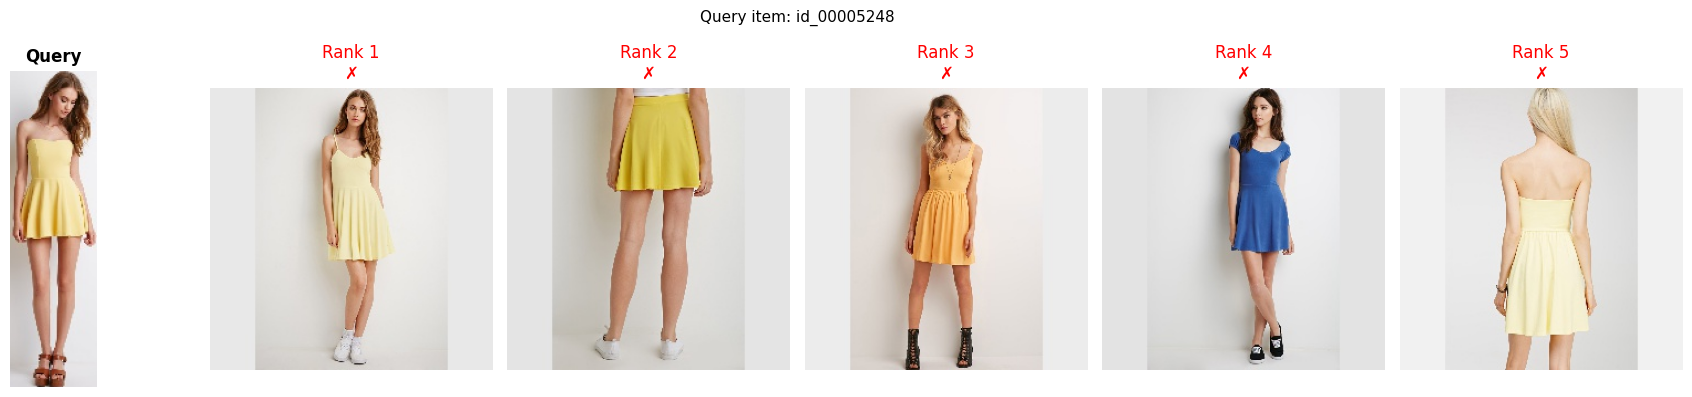

In [9]:
test_row   = gallery_df.sample(1).iloc[0]
test_img   = Image.open(test_row['full_path']).convert('RGB')
test_crop  = yolo_crop(test_img)
test_emb   = clip_image_embedding([test_crop])

labels, distances = hnsw_index.knn_query(test_emb, k=6)
retrieved_ids      = [all_item_ids[l] for l in labels[0][1:]]  # skip self

fig, axes = plt.subplots(1, 6, figsize=(18, 4))
axes[0].imshow(test_crop); axes[0].set_title('Query', fontweight='bold')
axes[0].axis('off')
for col, (lid, dist) in enumerate(zip(labels[0][1:], distances[0][1:]), 1):
    match_row = gallery_df.iloc[lid]
    match_img = Image.open(match_row['full_path']).convert('RGB')
    axes[col].imshow(match_img)
    is_correct = match_row['item_id'] == test_row['item_id']
    axes[col].set_title(
        f"Rank {col}\n{'✓ MATCH' if is_correct else '✗'}",
        color='green' if is_correct else 'red')
    axes[col].axis('off')
plt.suptitle(f"Query item: {test_row['item_id']}", fontsize=11)
plt.tight_layout()
plt.show()

In [10]:
config = {
    'alpha': ALPHA,
    'clip_model': CLIP_MODEL,
    'yolo_model': YOLO_MODEL,
    'embed_dim': EMBED_DIM,
    'n_gallery': n_valid,
    'hnsw_ef': HNSW_EF,
    'hnsw_m': HNSW_M,
}
with open(os.path.join(INDEX_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)
print(json.dumps(config, indent=2))

{
  "alpha": 0.7,
  "clip_model": "ViT-B-32",
  "yolo_model": "yolov8n.pt",
  "embed_dim": 512,
  "n_gallery": 12612,
  "hnsw_ef": 200,
  "hnsw_m": 16
}
